In [ ]:
!pip install qiskit qiskit-aer --upgrade

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Initialize simulator
sim = AerSimulator()

# Create a single-qubit circuit with one classical bit
qc = QuantumCircuit(1, 1)

# --- Apply sequence of single-qubit gates ---
qc.x(0)        # Pauli-X (NOT gate)
qc.h(0)        # Hadamard (superposition)
qc.s(0)        # Phase gate (π/2)
qc.t(0)        # T gate (π/4)
qc.rz(0.5, 0)  # Z-axis rotation by 0.5 radians

# Measure final state
qc.measure_all()

# Display circuit
print("Quantum Circuit:")
print(qc.draw())

# --- Run simulation ---
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

# --- Display results ---
counts = result.get_counts()
print("\nMeasurement Counts:", counts)


Classification report for classifier SVC(C=100, gamma=0.001):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.89      0.89      0.89        53
           2       0.98      1.00      0.99        53
           3       0.96      0.85      0.90        53
           4       0.93      0.93      0.93        57
           5       0.95      0.98      0.96        56
           6       0.96      0.93      0.94        54
           7       0.96      0.94      0.95        54
           8       0.81      0.90      0.85        52
           9       0.89      0.89      0.89        55

    accuracy                           0.93       540
   macro avg       0.93      0.93      0.93       540
weighted avg       0.93      0.93      0.93       540




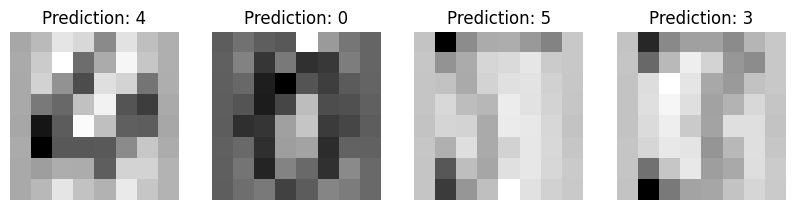

In [20]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Note: 'load_digits' is a smaller 8x8 version.
# For the full 28x28 version, use fetch_openml('mnist_784')
digits = datasets.load_digits()

# 2. Preprocess the data
# Flatten the images from (8, 8) to (64,)
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Split into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.3, shuffle=False
)

# Scaling is CRITICAL for SVMs (they are distance-based)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Create and Train the SVM Classifier
# Using the RBF (Radial Basis Function) kernel
clf = svm.SVC(gamma=0.001, C=100)
clf.fit(X_train, y_train)

# 4. Evaluation
predicted = clf.predict(X_test)

print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")

# 5. Visualize some predictions
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")
plt.show()